In [82]:
# uncomment following line to make an html
!jupyter nbconvert --to html GOTHAAM_Validation.ipynb

[NbConvertApp] Converting notebook CAESAR_Validation.ipynb to html
[NbConvertApp] Writing 7693719 bytes to CAESAR_Validation.html


In [18]:
import importlib
import wind_utils
import numpy as np
import netCDF4
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


Differences (python_port - nimbus):
  UIC: N=19392  max|diff|=2.625e-05  rms=5.890e-06  NaN-mismatch=0
  VIC: N=19392  max|diff|=2.682e-05  rms=6.467e-06  NaN-mismatch=0
  WIC: N=19392  max|diff|=1.057e-06  rms=2.463e-07  NaN-mismatch=0
  WINDSFLG: N=19394  max|diff|=0.000e+00  rms=0.000e+00  NaN-mismatch=0


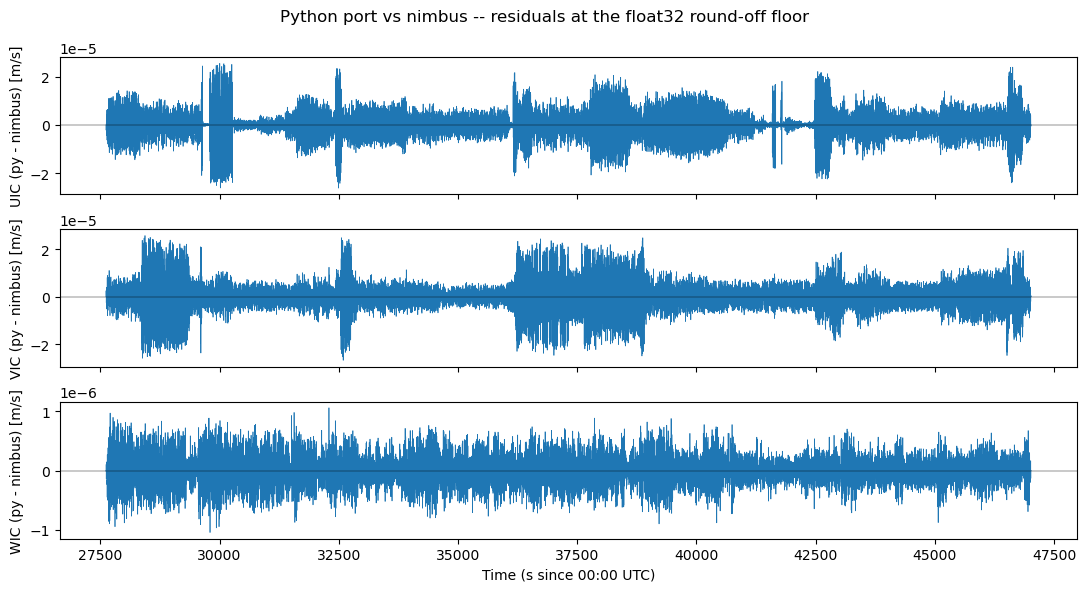

In [24]:
# ============================================================
# Validate Python port of nimbus gust.c against UIC/VIC/WIC
# in GOTHAAMrf18.nc. Should match to float32 round-off.
# ============================================================
import importlib, numpy as np, netCDF4, pandas as pd, matplotlib.pyplot as plt
import wind_utils
importlib.reload(wind_utils)

NC_PATH = "GOTHAAMrf18.nc"

# read the variables nimbus' WIC depends on, decode -32767 -> NaN
nc = netCDF4.Dataset(NC_PATH)
def col(name):
    a = nc.variables[name][:]
    return a.filled(np.nan).astype(np.float64) if np.ma.isMaskedArray(a) else a.astype(np.float64)
needed = ["Time","TASX","VEWC","VNSC","GGVSPD","PITCH","ROLL","THDG",
          "AKRD","SSLIP","UIC","VIC","WIC","WINDSFLG",
          "ADIFR","QCF","PSXC","PSFD","BDIFR"]   # extra cols for the aoa-coefs path
df = pd.DataFrame({n: col(n) for n in needed})
nc.close()

# run the port using the file's AKRD / SSLIP (so we test gust.c geometry alone)
u_py, v_py, w_py, wf_py = wind_utils.calc_winds(
    df, aircraft="C130",
    akrd=df["AKRD"].to_numpy(), sslip=df["SSLIP"].to_numpy(),
    tas_var="TASX", vew_var="VEWC", vns_var="VNSC", vspd_var="GGVSPD",
    dt=1.0, wind_type="corrected",
)

def report(name, ref, test):
    diff = test - ref
    valid = np.isfinite(ref) & np.isfinite(test)
    nan_mismatch = int((np.isfinite(ref) ^ np.isfinite(test)).sum())
    d = diff[valid]
    print(f"  {name}: N={valid.sum():>5d}  max|diff|={np.max(np.abs(d)):.3e}  "
          f"rms={np.sqrt(np.mean(d*d)):.3e}  NaN-mismatch={nan_mismatch}")

print("Differences (python_port - nimbus):")
report("UIC",      df["UIC"].to_numpy(),      u_py)
report("VIC",      df["VIC"].to_numpy(),      v_py)
report("WIC",      df["WIC"].to_numpy(),      w_py)
report("WINDSFLG", df["WINDSFLG"].to_numpy(), wf_py)

# plot residuals
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
t = df["Time"].to_numpy()
for ax, name, py in zip(axes, ["UIC","VIC","WIC"], [u_py, v_py, w_py]):
    ax.plot(t, py - df[name].to_numpy(), linewidth=0.5)
    ax.set_ylabel(f"{name} (py - nimbus) [m/s]")
    ax.axhline(0, color="k", linewidth=0.3)
axes[-1].set_xlabel("Time (s since 00:00 UTC)")
fig.suptitle("Python port vs nimbus -- residuals at the float32 round-off floor")
plt.tight_layout()
plt.show()


AKRD_COEFF     (clean) = [5.224720478057861, 14.997305870056152, 0.0]
AKRD_COEFF_ALT (dirty) = [4.631500244140625, 13.830740928649902, 0.0]
SSRD coefs              = [0.550000011920929, 12.809800148010254]

Differences (python_port w/ AOA-coef switch - nimbus):
  AKRD: N=19392  max|diff|=4.440e-07  rms=1.116e-07  NaN-mismatch=10
  SSLIP: N=19394  max|diff|=1.617e+00  rms=1.642e-02  NaN-mismatch=8
  UIC: N=19392  max|diff|=2.612e-05  rms=5.890e-06  NaN-mismatch=0
  VIC: N=19392  max|diff|=2.690e-05  rms=6.468e-06  NaN-mismatch=0
  WIC: N=19392  max|diff|=1.178e-06  rms=2.064e-07  NaN-mismatch=0
  WINDSFLG: N=19394  max|diff|=0.000e+00  rms=0.000e+00  NaN-mismatch=8

Mach-threshold switch: 3044 samples used ALT (dirty), 16358 used clean.


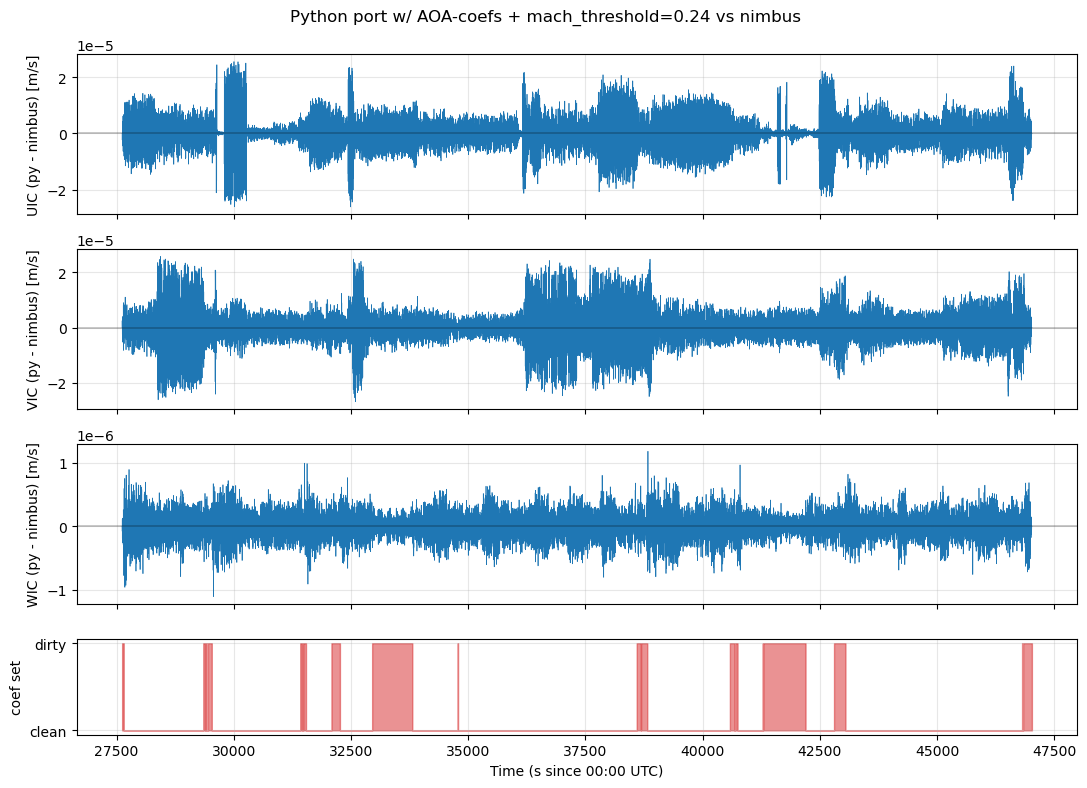

In [25]:
# ============================================================
# Validation #2: same comparison, but recomputing AKRD inside
# calc_winds() from the two AOA coefficient sets stored in the
# netCDF metadata, with the Mach-based switch (mach_threshold).
# Should match nimbus to the same float32 round-off as Validation #1.
# ============================================================
importlib.reload(wind_utils)

# pull both coef sets straight from the file's AKRD variable metadata
with netCDF4.Dataset(NC_PATH) as nc:
    aoa_coefs     = [float(c) for c in nc.variables["AKRD"].getncattr("AKRD_COEFF")]
    aoa_coefs_alt = [float(c) for c in nc.variables["AKRD"].getncattr("AKRD_COEFF_ALT")]
    aos_coefs     = [float(c) for c in nc.variables["SSRD"].getncattr("CalibrationCoefficients")]
print(f"AKRD_COEFF     (clean) = {aoa_coefs}")
print(f"AKRD_COEFF_ALT (dirty) = {aoa_coefs_alt}")
print(f"SSRD coefs              = {aos_coefs}")

u_py2, v_py2, w_py2, wf_py2 = wind_utils.calc_winds(
    df, aircraft="C130",
    aoa_coefs=aoa_coefs, aoa_coefs_alt=aoa_coefs_alt,
    mach_threshold=0.24,
    aos_coefs=aos_coefs,
    tas_var="TASX", vew_var="VEWC", vns_var="VNSC", vspd_var="GGVSPD",
    qcf_var="QCF", psf_var="PSFD",
    dt=1.0, wind_type="corrected",
)

# calc_winds dropped the recomputed AKRD/SSLIP into df['AKRD_test'] / df['SSLIP_test']
akrd_py2  = df["AKRD_test"].to_numpy()
sslip_py2 = df["SSLIP_test"].to_numpy()

print()
print("Differences (python_port w/ AOA-coef switch - nimbus):")
report("AKRD",  df["AKRD"].to_numpy(),  akrd_py2)
report("SSLIP", df["SSLIP"].to_numpy(), sslip_py2)
report("UIC",   df["UIC"].to_numpy(),   u_py2)
report("VIC",   df["VIC"].to_numpy(),   v_py2)
report("WIC",   df["WIC"].to_numpy(),   w_py2)
report("WINDSFLG", df["WINDSFLG"].to_numpy(), wf_py2)

# how many samples ended up using each coefficient set
mach_dry_used = wind_utils.calc_mach_dry(df["QCF"].to_numpy(), df["PSFD"].to_numpy())
n_alt   = int(np.sum((mach_dry_used <  0.24) & np.isfinite(mach_dry_used)))
n_clean = int(np.sum((mach_dry_used >= 0.24) & np.isfinite(mach_dry_used)))
print(f"\nMach-threshold switch: {n_alt} samples used ALT (dirty), {n_clean} used clean.")

# plot residuals + highlight where the dirty coef set was used
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True,
                        gridspec_kw={"height_ratios": [1, 1, 1, 0.6]})
t = df["Time"].to_numpy()
for ax, name, py in zip(axes[:3], ["UIC","VIC","WIC"], [u_py2, v_py2, w_py2]):
    ax.plot(t, py - df[name].to_numpy(), linewidth=0.5)
    ax.set_ylabel(f"{name} (py - nimbus) [m/s]")
    ax.axhline(0, color="k", linewidth=0.3)
    ax.grid(True, alpha=0.3)

# bottom panel: which coef set was active
axes[3].fill_between(t, 0, (mach_dry_used < 0.24).astype(float),
                     step="mid", alpha=0.5, color="C3", label="ALT (dirty)")
axes[3].set_ylabel("coef set")
axes[3].set_yticks([0, 1]); axes[3].set_yticklabels(["clean", "dirty"])
axes[3].set_xlabel("Time (s since 00:00 UTC)")
axes[3].grid(True, alpha=0.3)
fig.suptitle("Python port w/ AOA-coefs + mach_threshold=0.24 vs nimbus")
plt.tight_layout()
plt.show()


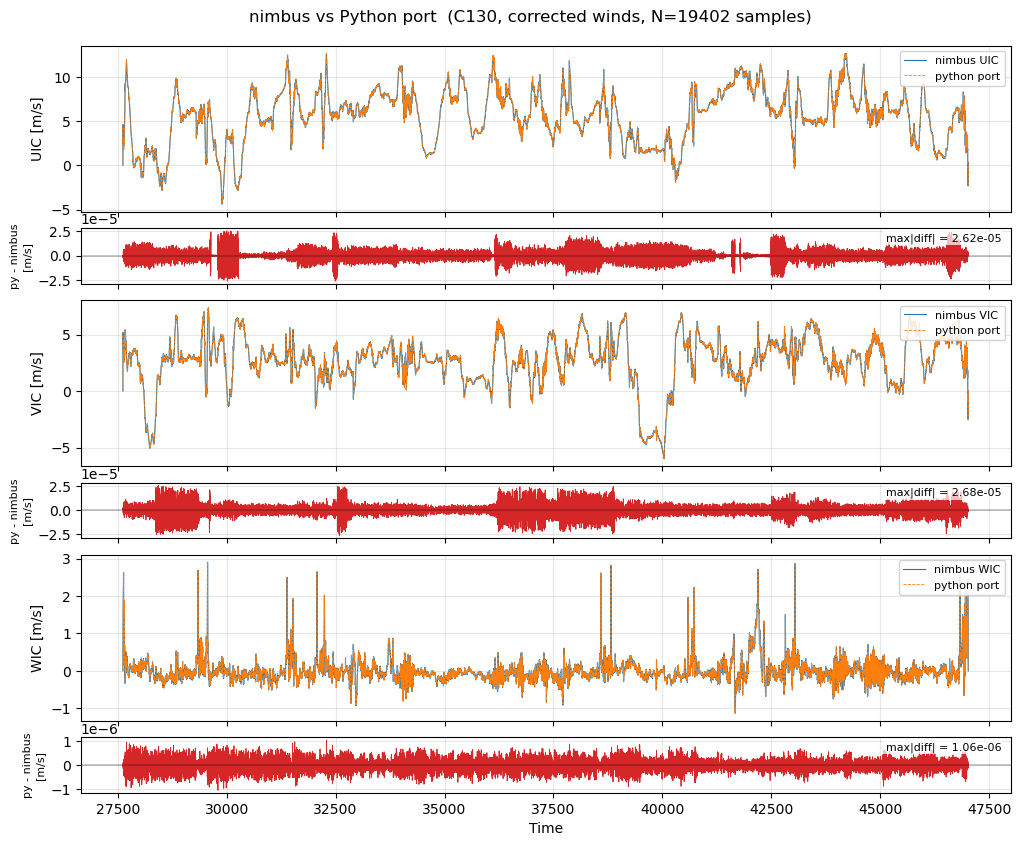

In [26]:
# ============================================================
# Side-by-side time series of nimbus UIC/VIC/WIC vs Python port.
# plot_winds_comparison() runs calc_winds() internally using the
# file's AKRD/SSLIP and overlays the two curves with a residual
# subplot beneath each component.
# ============================================================
importlib.reload(wind_utils)

# Full flight
fig, axes = wind_utils.plot_winds_comparison(df, aircraft="C130")
plt.show()

# Optional: zoom into a sub-interval to inspect detail
# fig2, _ = wind_utils.plot_winds_comparison(df, aircraft="C130",
#                                            time_range=(35000, 40000))
# plt.show()
